# SU(2) qudit RB

This tutorial shows how to benchmark the group of global $\text{SU}(2)$ rotations acting on a single spin-$j$ qudit, using the *rank-1 synthetic-SPAM randomized benchmarking* protocol (abbreviated SSR1RB, or just R1RB) introduced in [*Randomized Benchmarking with Synthetic Quantum Circuits*](https://arxiv.org/abs/2412.18578) by Fan, Murray, Ladd, Young, and Blume-Kohout.

## What is SU(2) qudit RB?

Many hardware platforms — spin qudits realized in nuclear or electron spins, superconducting circuits with engineered rotational symmetry, atomic ensembles — natively implement *global $\text{SU}(2)$ rotations* $e^{-i \theta \vec{n} \cdot \vec{J}}$ on a spin-$j$ Hilbert space of dimension $d = 2j + 1$. These operations are also the "transversal" logical gates of recently proposed single-spin quantum error-correcting codes.

Benchmarking this gate set is not a job for standard RB. For $j > 1/2$ the spin-$j$ representation of $\text{SU}(2)$ is not a unitary 2-design, and the superoperator representation of $\text{SU}(2)$ on the space of spin-$j$ operators is highly reducible: it decomposes into irreps labeled by $k = 0, 1, \ldots, 2j$ (spanned by the rank-$k$ spherical tensor operators). A standard RB experiment on such a system produces a *sum of up to $2j + 1$ exponential decays* whose weights depend strongly on SPAM — a signal that is neither SPAM-robust nor practical to fit.

The R1RB protocol solves this by isolating each irrep's signal individually. It produces:

- a **per-irrep decay parameter** $f_k$ for each $k = 0, \ldots, 2j$, describing how the component of a state in irrep $k$ decays per gate under the $\text{SU}(2)$-twirled noise; and
- **per-irrep error rates** $p_k$, obtained from the $f_k$ by inverting a "Fourier" (recoupling) matrix $F$, satisfying $\sum_k p_k = 1$. The rate $p_k$ is the rate of *weight-$k$* $\text{SU}(2)$-twirled errors — directly relevant to spin codes, which correct errors of weight $k = 1, 2$.

Two ingredients make this work:

1. **Synthetic SPAM.** No physical state lies inside a single nontrivial irrep. Instead, each random gate sequence is run $2j+1$ times, once from each $J_z$ eigenstate $|\ell\rangle\langle\ell|$, and the resulting $(2j+1) \times (2j+1)$ matrix $P$ of outcome probabilities is combined in post-processing as $\mathrm{diag}(M P M^T)$. The orthogonal matrix $M$ synthesizes the (unphysical) diagonal spherical tensors $T^{(k)}_0$ as both initial states and measurement effects, one per irrep.
2. **Rank-1 weighting.** The first gate of each sequence is "hidden": the final inversion gate undoes only gates $2, \ldots, m$, so the net ideal operation is the random first gate $g$ rather than the identity. Weighting each sequence's contribution to irrep $k$ by $(2k+1) P_k(\cos\beta_g)$ — a Legendre polynomial in that hidden gate's middle Euler angle — makes the decay estimates robust to *arbitrary* (fixed, gate-independent) SPAM error, at far lower sampling cost than $\text{SU}(2)$ character RB. We demonstrate this robustness explicitly below.

pyGSTi implements the protocol as a self-contained `Design → DataSimulator → Protocol → Results` family in `pygsti.protocols.su2rb`, supported by the representation-theory tools in `pygsti.tools.su2tools` (the `SpinJ` class) and `pygsti.tools.wignersymbols` (exact Clebsch-Gordan and Wigner 6-j symbols).

In [1]:
import numpy as np
import pygsti
from pygsti.protocols import SU2QuditRBDesign, SU2QuditRBSimulator, SU2QuditRB
from pygsti.protocols.su2rb import jz_dephasing, jz_rotation, predicted_zero_noise_variance
from pygsti.tools.su2tools import SpinJ

## Creating an experiment design

An `SU2QuditRBDesign` takes the spin $j$ (any non-negative integer or half-integer), the RB depths $m$ (the number of Haar-random gates in a sequence; each depth must be $\geq 1$), and the number of random sequences per depth. Here we use a spin-$3/2$ qudit, so $d = 4$ and the analysis will report four decays $f_0, \ldots, f_3$.

In [2]:
j = 1.5
depths = [1, 2, 4, 8, 16, 32]
circuits_per_depth = 300

edesign = SU2QuditRBDesign(j, depths, circuits_per_depth, seed=2026)
print(f'dim = {edesign.dim}, circuits per depth = {len(edesign.circuit_lists[0])}')

dim = 4, circuits per depth = 1200


Each sampled sequence generates a *batch* of $2j + 1 = 4$ circuits that share the same gates and differ only in their state prep, so there are `circuits_per_depth * (2j+1) = 1200` circuits at each depth. A circuit consists of a `rho{l}` prep layer (preparing the $J_z$ eigenstate $|\ell\rangle\langle\ell|$, with `rho0` the highest-weight state $|{+j}\rangle$), a sequence of `Gu` gate layers whose ZXZ Euler angles are carried as label *arguments*, and an `Mdefault` POVM layer:

In [3]:
print(edesign.circuit_lists[0][0])

Qubit Q0 ---|rho0|-|Gu(1.1242805922284176,1.2871831175752826,5.871867905148085)|-|Gu(0.0,0.0,0.0)|-|Mdefault|---



The last `Gu` layer inverts gates $2, \ldots, m$ of the sequence (at depth $m=1$ it is simply the identity, as above), leaving the random first gate as the net ideal operation. The per-sequence Legendre weights $P_k(\cos\beta)$ of that hidden first gate are precomputed and stored on the design as `charcores` aux data, alongside the Euler angles themselves — so the analysis never needs to parse circuit labels.

## Simulating data

`SU2QuditRBSimulator` simulates these circuits directly against a `SpinJ` representation (no pyGSTi `Model` is involved), applying an optional noise superoperator after every gate except the hidden first one. The module provides two simple noise channels: `jz_dephasing` (damps coherences between $J_z$ eigenstates) and `jz_rotation` (a coherent over-rotation about $J_z$). Any `(d^2, d^2)` superoperator acting on row-major-vectorized density matrices works, and channels compose by matrix multiplication:

In [4]:
spinj = SpinJ(j)
noise = jz_dephasing(spinj, gamma=0.02) @ jz_rotation(spinj, theta=0.05)

sim = SU2QuditRBSimulator(spinj, noise_channel=noise)
data = sim.run(edesign)

By default the simulator records *exact* outcome probabilities as floating-point "counts" (no shot noise). Pass `shots=N` (and optionally `seed`) to draw $N$ multinomial samples per circuit instead. For gate-*dependent* noise, pass a callable factory instead of an array; it is invoked per gate with that gate's own Euler angles:

In [5]:
def beta_dependent_dephasing(alpha, beta, gamma):
    return jz_dephasing(spinj, gamma=0.002 * (1 + np.cos(beta)**2))

sim_gate_dep = SU2QuditRBSimulator(spinj, noise_channel=beta_dependent_dephasing)

## Running the protocol

The `SU2QuditRB` protocol analyzes data as follows.

 1. It reconstructs each sequence's prep-by-effect probability matrix.
 2. It forms the weighted per-irrep estimators, and averages them over sequences at each depth.
 3. It fits each irrep's series to a single exponential $A_k f_k^{\,x}$ (with $x = m + 1$, the number of gates in a depth-$m$ sequence).
 4. It recovers the rates $\vec{p} = F^{-1} \vec{f}$ with propagated uncertainties.

Here's how we do all that in pyGSTi.

In [6]:
protocol = SU2QuditRB()
results = protocol.run(data)
results.rates_dataframe()

,irrep,decay_f,decay_f_stderr,rate_p,rate_p_stderr
0,0,1.000000,3.449487e-10,0.973307,0.002616
1,1,0.988736,1.097680e-03,0.019342,0.004287
2,2,0.972991,3.701346e-03,0.007068,0.004189
3,3,0.963107,5.341261e-03,0.000282,0.001894


The trivial irrep $k = 0$ always has $f_0 = 1$ exactly (the noise channel is trace-preserving), so it serves as a built-in sanity check. The rates sum to one, with $p_0$ interpreted as the probability of no error and $p_k$ as the rate of weight-$k$ errors; note that low-weight ($k = 1, 2$) errors are the ones correctable by spin codes.

Let's plot the per-irrep decay curves. The raw ingredients are all on the results object: `per_irrep_means` and `per_irrep_stderrs` hold the averaged estimators and their standard errors (shape `(dim, len(depths))`), and `fits[k].estimates` holds each irrep's fitted amplitude (`'b'`) and decay (`'p'`).

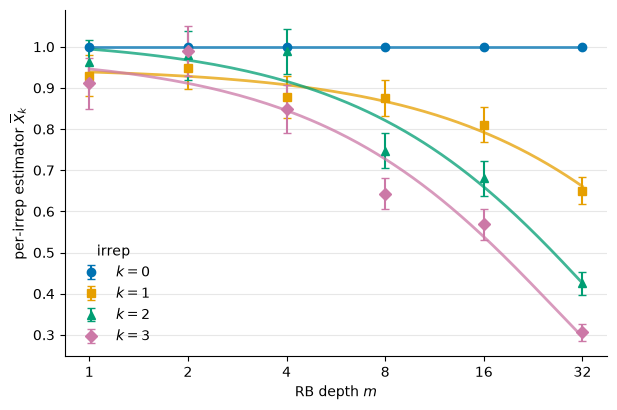

In [7]:
import matplotlib.pyplot as plt

colors    = ['#0072B2', '#E69F00', '#009E73', '#CC79A7']
markers   = ['o', 's', '^', 'D']
eb_kwargs = dict(linestyle='none', markersize=6, capsize=3)  # share across all errorbar series

fig, ax = plt.subplots(figsize=(7, 4.5))
m_grid = np.linspace(min(depths), max(depths), 200)
for k in range(results.dim):
    A_k = results.fits[k].estimates['b']
    f_k = results.fits[k].estimates['p']
    ax.errorbar(results.depths, results.per_irrep_means[k, :],
                yerr=results.per_irrep_stderrs[k, :], color=colors[k],
                marker=markers[k], label=f'$k = {k}$', **eb_kwargs)
    ax.plot(m_grid, A_k * f_k**(m_grid + 1), color=colors[k], linewidth=2, alpha=0.75)
ax.set_xscale('log', base=2)
ax.set_xticks(results.depths, labels=[str(m) for m in results.depths])
ax.set_xlabel('RB depth $m$')
ax.set_ylabel(r'per-irrep estimator $\overline{X}_k$')
ax.legend(title='irrep', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.show()

## Checking the estimates against exact theory

Because we simulated with a known, gate-independent noise channel, we can compute the decays this experiment *should* recover: $f_k$ is the eigenvalue of the $\text{SU}(2)$-twirled noise channel on irrep $k$, i.e. $f_k = \mathrm{Tr}(\Pi_k \, \mathcal{E}) / (2k+1)$ with $\Pi_k$ the irrep projector. `SpinJ` exposes those projectors, as well as the recoupling matrix $F$:

In [8]:
import pandas as pd

f_exact = np.array([np.real(np.vdot(Pi_k, noise)) / (2 * k + 1)
                    for k, Pi_k in enumerate(spinj.irrep_stdmx_projectors)])
p_exact = np.linalg.solve(spinj.decay_recoupling_matrix, f_exact)

pd.DataFrame({'f_fit': results.decays, 'f_exact': f_exact,
              'f_stderr': results.decay_stderrs,
              'p_fit': results.rates, 'p_exact': p_exact})

,f_fit,f_exact,f_stderr,p_fit,p_exact
0,1.000000,1.000000,3.449487e-10,0.973307,0.972511
1,0.988736,0.985982,1.097680e-03,0.019342,0.019456
2,0.972991,0.973985,3.701346e-03,0.007068,0.005030
3,0.963107,0.961758,5.341261e-03,0.000282,0.003004


The fitted decays land within a few parts in a thousand of the exact twirled-channel eigenvalues — within a small multiple of the quoted standard errors. (The residual fluctuations come from averaging over finitely many random sequences — even with exact per-circuit probabilities, the rank-1 weights vary from sequence to sequence. More `circuits_per_depth` tightens them.)

## SPAM robustness

The headline feature of the rank-1 weighting is that *fixed SPAM error cannot bias the decays*: it only rescales the fitted amplitudes $A_k$. The simulator provides a cheap way to demonstrate this. `compute_nonspam_compositions` caches the composed noisy superoperator of every sampled sequence, and `probabilities_from_compositions` re-derives outcome probabilities under arbitrary preps and POVM effects without re-simulating any circuits — this is the machinery behind the SPAM-robustness figures in the paper.

Here we corrupt *both* the preps and the measurement with a fixed unitary error $V = e^{i \, 0.2 J_x}$ — a substantial SPAM error that is not diagonal in the $J_z$ eigenbasis:

In [9]:
V = spinj.expm_iJx(0.2)[0]
spam_ops = np.zeros((edesign.dim, edesign.dim**2), dtype=complex)
for ell in range(edesign.dim):
    projector = np.zeros((edesign.dim, edesign.dim), dtype=complex)
    projector[ell, ell] = 1.0
    spam_ops[ell, :] = (V @ projector @ V.conj().T).ravel()

compositions = sim.compute_nonspam_compositions(edesign)
probs = sim.probabilities_from_compositions(compositions, statepreps=spam_ops, povm=spam_ops)

Now assemble the perturbed probabilities into a `DataSet` and rerun the protocol on it:

In [10]:
from pygsti.data import DataSet

ds_spam = DataSet(collision_action='aggregate')
ds_spam.repType = np.float64
outcome_labels = [str(ell) for ell in range(edesign.dim)]
for depth_idx, circuits_at_depth in enumerate(edesign.circuit_lists):
    for circuit, seq_idx, prep_idx in zip(circuits_at_depth,
                                          edesign.seq_index[depth_idx],
                                          edesign.prep_index[depth_idx]):
        prob_row = probs[depth_idx][seq_idx, prep_idx, :]
        ds_spam.add_count_dict(circuit, {ol: float(p) for ol, p in zip(outcome_labels, prob_row)})
ds_spam.done_adding_data()

results_spam = protocol.run(pygsti.protocols.ProtocolData(edesign, ds_spam))

pd.DataFrame({'f (ideal SPAM)': results.decays,
              'f (corrupted SPAM)': results_spam.decays,
              'A (ideal SPAM)': [fit.estimates['b'] for fit in results.fits],
              'A (corrupted SPAM)': [fit.estimates['b'] for fit in results_spam.fits]})

,f (ideal SPAM),f (corrupted SPAM),A (ideal SPAM),A (corrupted SPAM)
0,1.000000,1.000000,1.000000,1.000000
1,0.988736,0.988979,0.960339,0.912305
2,0.972991,0.971752,1.050348,0.943885
3,0.963107,0.963224,1.019938,0.811178


The decays shift by well under their standard errors, while the amplitudes absorb the SPAM error — exactly the division of labor the protocol is designed to enforce. An unweighted synthetic-SPAM analysis (plain $\mathrm{diag}(M P M^T)$ without the rank-1 weights) requires SPAM to be diagonal in the $J_z$ eigenbasis, and would be biased by this $V$.

## Sample-complexity diagnostics

The estimator variance of synthetic RB protocols is dominated by the spread of the post-processing weights rather than by shot noise, so it does *not* vanish in the zero-noise limit. The paper derives this zero-noise variance exactly, and pyGSTi exposes it as `predicted_zero_noise_variance(j, k)` — a useful planning tool, since $\mathrm{Var}(X_k)/N$ sets how many sequences $N$ you need for a target precision on irrep $k$'s decay. `variance_diagnostic` compares the prediction against the empirical per-sequence variance from a run (they agree at low noise and short depths, in an order-of-magnitude sense):

In [11]:
diagnostic = results.variance_diagnostic(depth_index=0)
pd.DataFrame({'k': list(diagnostic.keys()),
              'predicted Var(X_k), zero noise': [v[0] for v in diagnostic.values()],
              'empirical Var(X_k) at depth 1': [v[1] for v in diagnostic.values()]})

,k,"predicted Var(X_k), zero noise",empirical Var(X_k) at depth 1
0,0,0.000000,1.150147e-32
1,1,0.532000,7.673597e-01
2,2,1.000000,9.203100e-01
3,3,1.638667,1.124810e+00


The variances grow slowly with $k$ (and with $j$) — this weak dimension-dependence is what makes the protocol efficient. For comparison, the paper shows that $\text{SU}(2)$ *character RB* incurs variances more than two orders of magnitude larger for spins of experimental interest. (The poor efficiency of character RB is why we haven't bothered to include it in a pyGSTi release.)

## Writing and reading to/from disk

Everything serializes with the standard pyGSTi I/O idioms. For a real experiment you would write an empty protocol data directory, run the circuits on hardware, fill in `data/dataset.txt`, and read it back — the design's Euler angles, sequence indices, and Legendre weights round-trip as JSON aux files automatically:

In [12]:
pygsti.io.write_empty_protocol_data('../../../tutorial_files/test_su2rb_dir', edesign, clobber_ok=True)

# -- fill in ../../../tutorial_files/test_su2rb_dir/data/dataset.txt with hardware counts --

loaded = pygsti.io.read_data_from_dir('../../../tutorial_files/test_su2rb_dir')
print(type(loaded.edesign).__name__)

SU2QuditRBDesign


Results round-trip through `write` and `pygsti.io.read_results_from_dir`:

In [13]:
results.write('../../../tutorial_files/test_su2rb_results')
results_from_disk = pygsti.io.read_results_from_dir('../../../tutorial_files/test_su2rb_results')
results_from_disk.for_protocol['SU2QuditRB'].rates_dataframe()

,irrep,decay_f,decay_f_stderr,rate_p,rate_p_stderr
0,0,1.000000,3.449487e-10,0.973307,0.002616
1,1,0.988736,1.097680e-03,0.019342,0.004287
2,2,0.972991,3.701346e-03,0.007068,0.004189
3,3,0.963107,5.341261e-03,0.000282,0.001894
